In [6]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def load_results_table(results_dir, methods_list, use_coords, use_demographic, file_name="aggregated_results.json"):
    agg_list = []
    for method in methods_list:
        if use_demographic and use_coords:
            folder_name = f"{method}_coords_demographic_radiomics"
        elif use_demographic and not use_coords:
            folder_name = f"{method}_demographic_radiomics"
        elif not use_demographic and use_coords:
            folder_name = f"{method}_coords_radiomics"
        else:
            folder_name = f"{method}_radiomics"
        aggregated_result_dir = Path(results_dir)/folder_name / file_name
        df = pd.read_json(aggregated_result_dir)
        agg_list.append(df)
    final_df = pd.concat(agg_list, ignore_index=True)
    # final_df = final_df[['model', 'Accuracy_Mean', 'ROC_AUC_Mean']]
    display(final_df)
    print("Average across models:")
    display(pd.DataFrame(final_df.mean(numeric_only=True)).T)

# Data Statistics

In [2]:
import os
import json
import pandas as pd

def read_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return data

In [3]:
data_root = "/home/reza/Documents/Reza_projects/08_drarabi_lymphnodes/new_dataset"
dataset_dicts = read_json(os.path.join(data_root, "dataset_directories.json"))
center_1 = dataset_dicts['Masih-SUV']
center_2 = dataset_dicts['Razavi-SUV']
combined_centers = center_1 + center_2

In [23]:
def change_to_df(center_data, center_name):
    agg_list = []
    for p_info in center_data:
        radiomics_dir = os.path.join(data_root, center_name, str(list(p_info.keys())[0]), "radiomics", 'radiomics_each_lesion.json')
        nodes_radiomics = read_json(radiomics_dir)
        info = dict(list(p_info.values())[0])
        info['lesion_count'] = len(nodes_radiomics)
        agg_list.append(info)

    center_df = pd.DataFrame(agg_list)
    center_df = center_df.rename(columns={"Gender(Male=0, Fmale:1)": "Gender(Male:0, Female:1)"})
    center_df = center_df.drop(columns=['Stage'])
    return center_df
center_1_df = change_to_df(center_1, center_name='Masih-SUV')
center_2_df = change_to_df(center_2, center_name='Razavi-SUV')
combined_centers_df = pd.concat([center_1_df, center_2_df], ignore_index=True)


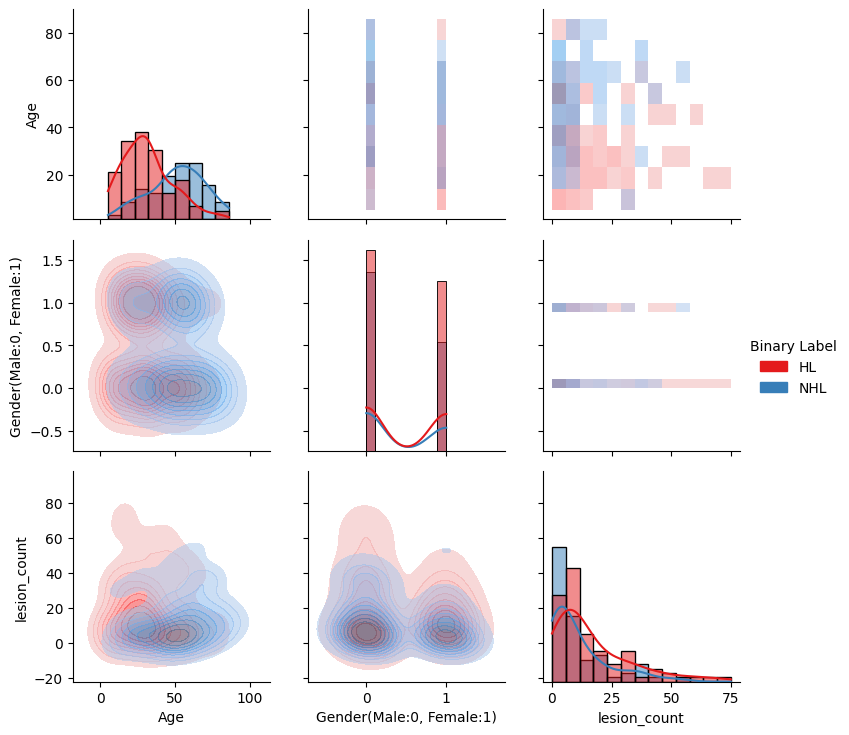

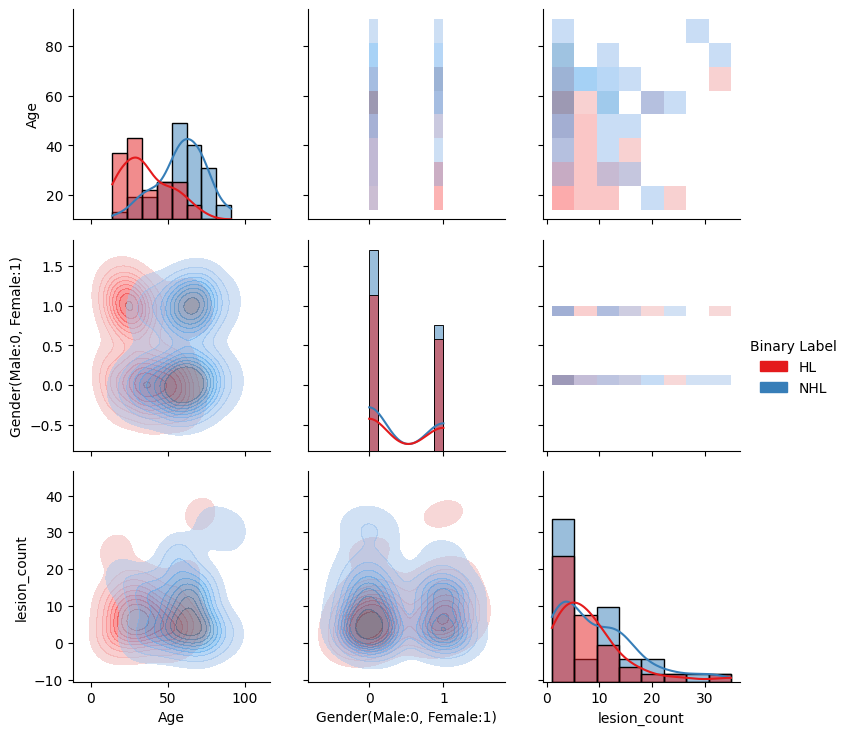

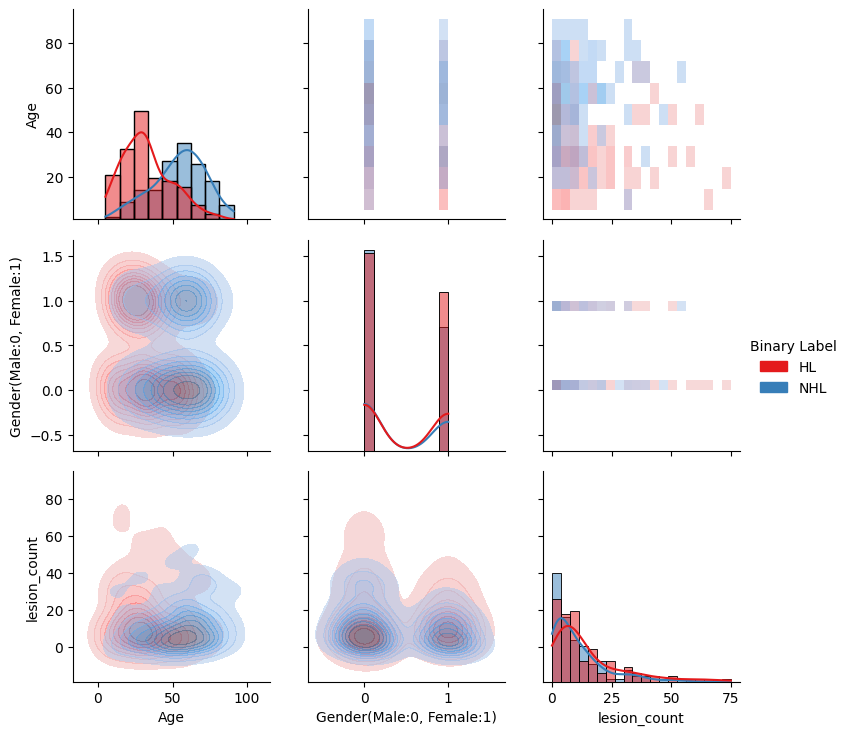

In [24]:
def plot_pairgrid(center_df):
    g = sns.PairGrid(data=center_df, hue="Binary Label", palette="Set1")
    g.map_upper(sns.histplot, alpha=0.5)
    g.map_lower(sns.kdeplot, fill=True, alpha=0.5)
    g.map_diag(sns.histplot, kde=True, alpha=0.5)
    g.add_legend()

plot_pairgrid(center_1_df)
plot_pairgrid(center_2_df)
plot_pairgrid(combined_centers_df)

In [29]:
def center_statistics(center_df, label):
    center_df = center_df.copy()
    center_df = center_df[center_df['Binary Label']==label]
    print(f"Gender distribution:")
    print(center_df['Gender(Male:0, Female:1)'].value_counts(normalize=False))
    print(center_df['Gender(Male:0, Female:1)'].value_counts(normalize=True))
    # age mean and std
    print("Age statistics:")
    print(center_df['Age'].describe())
    print("number of lesions statistics: ")
    print(center_df['lesion_count'].describe())


center_statistics(center_1_df, label='NHL')

Gender distribution:
Gender(Male:0, Female:1)
0    41
1    25
Name: count, dtype: int64
Gender(Male:0, Female:1)
0    0.621212
1    0.378788
Name: proportion, dtype: float64
Age statistics:
count    66.000000
mean     51.287879
std      18.238392
min      12.000000
25%      40.000000
50%      52.000000
75%      63.750000
max      86.000000
Name: Age, dtype: float64
number of lesions statistics: 
count    66.000000
mean     10.863636
std      12.241024
min       0.000000
25%       2.000000
50%       6.000000
75%      15.000000
max      53.000000
Name: lesion_count, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

def plot_2x2_summary(df, title=None, save_path=None, dpi=300):

    hue_col = "Binary Label"
    age_col = "Age"
    gender_col = "Gender(Male:0, Female:1)"
    lesion_col = "lesion_count"

    # Define a fixed palette so colors are consistent everywhere
    # (edit order if your labels are ["NHL","HL"] in the dataframe)
    hue_order = ["HL", "NHL"]
    palette = dict(zip(hue_order, sns.color_palette("Set1", n_colors=len(hue_order))))

    sns.set_context("talk")
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

    # TOP-LEFT: KDE Age vs Gender (NO per-axis legend)
    sns.kdeplot(
        data=df, x=age_col, y=gender_col, hue=hue_col,
        hue_order=hue_order, palette=palette,
        fill=True, alpha=0.35, common_norm=False, levels=8,
        legend=False, ax=axes[0, 0]
    )
    axes[0, 0].set_title("KDE: Age vs Gender")
    axes[0, 0].set_yticks([0, 1])
    axes[0, 0].set_yticklabels(["Male (0)", "Female (1)"])
    axes[0, 0].set_ylim(-0.5, 1.5)

    # TOP-RIGHT: Violin lesion_count (no legend anyway)
    sns.violinplot(
        data=df, x=hue_col, y=lesion_col,
        order=hue_order, palette=palette,
        inner="quartile", cut=0, linewidth=1,
        ax=axes[0, 1]
    )
    sns.stripplot(
        data=df, x=hue_col, y=lesion_col,
        order=hue_order,
        color="k", size=2.5, alpha=0.25, jitter=0.25,
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("Lesion count distribution")

    # BOTTOM-LEFT: KDE Age vs lesion_count (NO per-axis legend)
    sns.kdeplot(
        data=df, x=age_col, y=lesion_col, hue=hue_col,
        hue_order=hue_order, palette=palette,
        fill=True, alpha=0.35, common_norm=False, levels=8,
        legend=False, ax=axes[1, 0]
    )
    axes[1, 0].set_title("KDE: Age vs lesion count")

    # BOTTOM-RIGHT: KDE Gender vs lesion_count (NO per-axis legend)
    sns.kdeplot(
        data=df, x=gender_col, y=lesion_col, hue=hue_col,
        hue_order=hue_order, palette=palette,
        fill=True, alpha=0.35, common_norm=False, levels=8,
        legend=False, ax=axes[1, 1]
    )
    axes[1, 1].set_title("KDE: Gender vs lesion count")
    axes[1, 1].set_xlim(-0.5, 1.5)
    axes[1, 1].set_xticks([0, 1])
    axes[1, 1].set_xticklabels(["Male (0)", "Female (1)"])

    # ---- ONE figure-level legend ----
    handles = [Patch(facecolor=palette[k], edgecolor="black", label=k) for k in hue_order]
    fig.legend(handles=handles, title="Binary Label", loc="lower right",  bbox_to_anchor=(1, 0.84), frameon=True)

    if title is not None:
        fig.suptitle(title, y=1.02, fontsize=16)

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()



# Usage (same as your previous calls)
plot_2x2_summary(center_1_df, title="Center 1", save_path="figures/center1_2x2.png")
plot_2x2_summary(center_2_df, title="Center 2", save_path="figures/center2_2x2.png")
plot_2x2_summary(combined_centers_df, title="Combined", save_path="figures/combined_2x2.png")